In this notebook, we consider the results for the filtered OU process.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import scipy
import scipy.linalg
import gaussian_crossings as gc

In [3]:
# Set simulation parameters.
T = 100.0    # Total simulation time (e.g., 10 time units)
tau_f = 0.01   # Correlation decay parameter
sigma = 1.0 # Standard deviation (amplitude) of the process

In [4]:
num_points_kappa = 100
kappa = torch.linspace(1e-2, 0.99, num_points_kappa)

num_points_zeta = 100
zeta = torch.linspace(0.0, sigma * 2.0, num_points_zeta) / sigma

mean_rates = torch.zeros(num_points_kappa, num_points_zeta)
fano_factors = torch.zeros(num_points_kappa, num_points_zeta)

In [5]:
for i in range(num_points_kappa):
    for j in range(num_points_zeta):
        # u is given by zeta[j]*sigma, and tau_e depends on kappa[i]
        u = zeta[j] * sigma
        tau_e = tau_f / kappa[i]
        model = gc.GaussianUpCrossings(r_func=gc.r_filtered_OU, u=u, tau=tau_e, kappa=kappa[i], sigma=sigma)
        mean_rates[i, j] = model.upcrossing_mean_rate()
        fano_factors[i, j] = model.upcrossing_fano_factor_CLT(epsilon_left=1e-2, epsilon_right=1e-5)

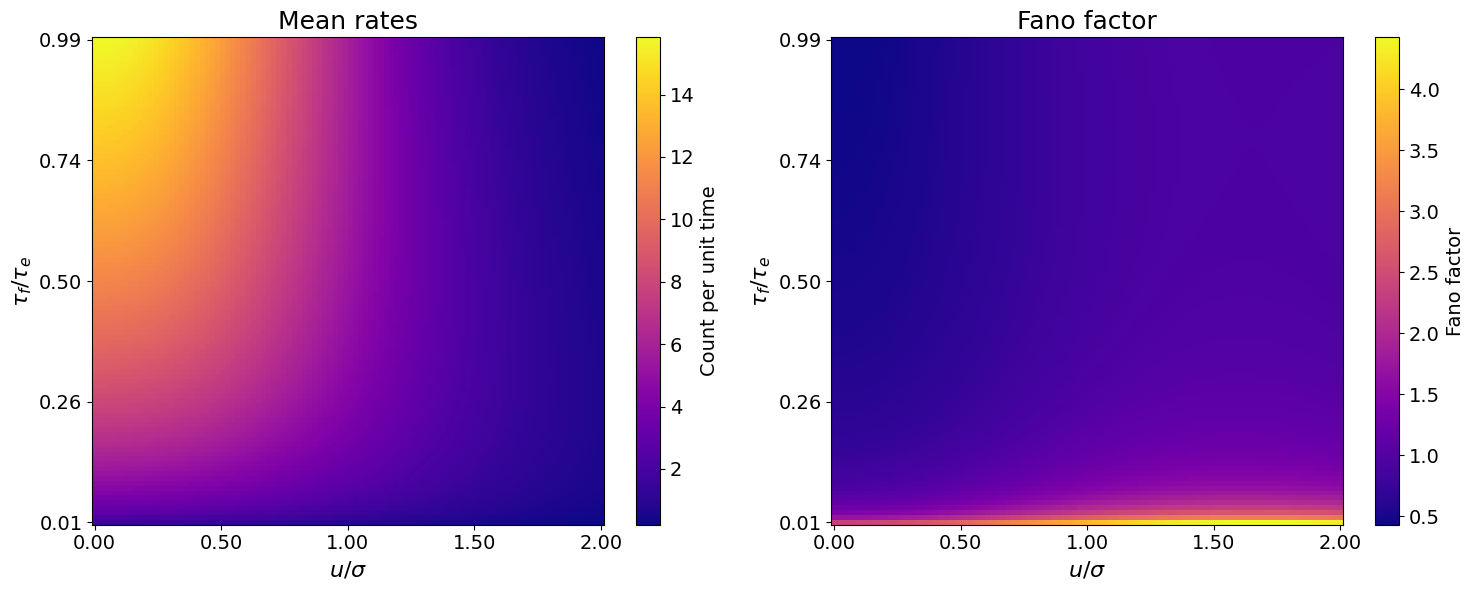

In [7]:
# Convert computed tensors to NumPy arrays for plotting
mean_rates_np = mean_rates.numpy()
fano_factors_np = fano_factors.numpy()
zeta_np = zeta.numpy()
kappa_np = kappa.numpy()

# -----------------------
# 3. Compute cell edges for arbitrary spacing
# -----------------------
def compute_edges(arr):
    """
    Given a 1D array (assumed sorted) representing cell centers,
    compute the cell edges so that each cell is centered on the given value.
    """
    edges = np.empty(len(arr) + 1)
    # Compute midpoints for interior edges
    edges[1:-1] = (arr[:-1] + arr[1:]) / 2.0
    # Extrapolate the first and last edges
    edges[0] = arr[0] - (arr[1] - arr[0]) / 2.0
    edges[-1] = arr[-1] + (arr[-1] - arr[-2]) / 2.0
    return edges

zeta_edges = compute_edges(zeta_np)
kappa_edges = compute_edges(kappa_np)

# -----------------------
# 4. Plotting using pcolormesh with the formal grid
# -----------------------
# Plotting parameters
cmap = 'plasma'
label_fontsize = 16
tick_fontsize = 14
title_fontsize = 18
cbar_labelsize = 14

# Define the number of ticks independently of the data spacing
num_ticks = 5
# Generate tick positions evenly over the full data range.
x_ticks = np.linspace(zeta_np.min(), zeta_np.max(), num_ticks)
y_ticks = np.linspace(kappa_np.min(), kappa_np.max(), num_ticks)

# Create a figure with two subplots (one for mean rates, one for Fano factors)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ---- Left subplot: Mean Rates ----
pc0 = axes[0].pcolormesh(zeta_edges, kappa_edges, mean_rates_np, shading='auto', cmap=cmap)
cbar0 = fig.colorbar(pc0, ax=axes[0])
cbar0.set_label("Count per unit time", fontsize=cbar_labelsize)
cbar0.ax.tick_params(labelsize=tick_fontsize)
axes[0].set_xlabel(r'$u/\sigma$', fontsize=label_fontsize)
axes[0].set_ylabel(r'$\tau_f/\tau_e$', fontsize=label_fontsize)
axes[0].set_title('Mean rates', fontsize=title_fontsize)
# Set independent ticks
axes[0].set_xticks(x_ticks)
axes[0].set_yticks(y_ticks)
axes[0].set_xticklabels([f"{val:.2f}" for val in x_ticks], fontsize=tick_fontsize)
axes[0].set_yticklabels([f"{val:.2f}" for val in y_ticks], fontsize=tick_fontsize)

# ---- Right subplot: Fano Factors ----
pc1 = axes[1].pcolormesh(zeta_edges, kappa_edges, fano_factors_np, shading='auto', cmap=cmap)
cbar1 = fig.colorbar(pc1, ax=axes[1])
cbar1.set_label("Fano factor", fontsize=cbar_labelsize)
cbar1.ax.tick_params(labelsize=tick_fontsize)
axes[1].set_xlabel(r'$u/\sigma$', fontsize=label_fontsize)
axes[1].set_ylabel(r'$\tau_f/\tau_e$', fontsize=label_fontsize)
axes[1].set_title('Fano factor', fontsize=title_fontsize)
# Set independent ticks
axes[1].set_xticks(x_ticks)
axes[1].set_yticks(y_ticks)
axes[1].set_xticklabels([f"{val:.2f}" for val in x_ticks], fontsize=tick_fontsize)
axes[1].set_yticklabels([f"{val:.2f}" for val in y_ticks], fontsize=tick_fontsize)
# save figure as png
# plt.savefig('../figures/filtered_OU.png')

plt.tight_layout()
plt.show()

In [10]:
model = gc.GaussianUpCrossings(r_func=gc.r_filtered_OU, u=0, tau=0.78, kappa=0.1, sigma=sigma)
print(model.upcrossing_fano_factor_CLT(epsilon_left=1e-2, epsilon_right=1e-5))

tensor([0.9300])
